# 6. 분류를 위해 미세 튜닝하기
지금까지 LLM 구조를 구현하고 사전 훈련했다. 오픈 AI 같이 사전 훈련된 가중치를 직접 만든 모델에 로드하는 방법을 배웠다. 이제 텍스트 분류 같은 특정 타깃 작업에 LLM을 미세튜닝하면 이런 작업의 가치가 드러난다. 이 장에서 다룰 구체적인 예제는 텍스트 메시지를 '스팸' 또는 '스팸 아님'으로 분류하는 것이다.

## 6.1 여러 가지 미세 튜닝 방법
언어 모델을 미세 튜닝하는 가장 일반적인 방법은 **지시 미세 튜닝(instruction fine-tuning)** 과 **분류 미세 튜닝(classification fine-tuning)** 이다. 지시 미세 튜닝은 구체적인 지시 데이터를 사용해 일련의 작업에서 언어 모델을 훈련한다.

분류 미세 튜닝에서는 모델이 '스팸'과 '스팸 아님' 같은 일련의 클래스 레이블을 인식하도록 훈련한다. 분류 작업의 예는 LLM과 이메일 필터링에 국한되지 않는다. 이미지에 있는 다양한 식물의 종을 식별하거나, 뉴스 기사를 스포츠, 정치, 기술 같은 토픽으로 분류하거나, 의료 이미지를 통해 양성 종양과 악성 종양을 구분한다.

핵심은 분류 미세 튜닝 모델이 훈련 과정에서 만난 클래스만 예측한다는 것이다. 에를 들어 모델은 입력 텍스트가 '스팸' 또는 '스팸 아님'인지 결정할 수 있지만 그외 다른 것은 말할 수 없다.

분류를 위해 미세 튜닝된 모델과 달리 지시 미세 튜닝 모델은 일반적으로 광범위한 작업을 수행할 수 있다. 분류 미세 튜닝된 모델은 고도로 전문화되었다고 볼 수 있으며, 일반적으로 다양한 작업을 처리하는 일반화된 모델보다 전문화된 모델을 개발하는 것이 더 쉽다.

## 6.2 데이터셋 준비
앞서 구현하고 사전 훈련한 GPT 모델을 수정해서 분류 미세튜닝을 수행할 수 있다. 분류 미세 튜닝에 대한 유용한 예제로 '스팸'과 '스팸 아님'으로 구성된 텍스트 메시지 데이터셋을 사용한다.

먼저 데이터셋을 다운로드한다.

In [1]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path}가 이미 있어 다운로드 및 압축 해제를 건너뜁니다.")
        return

    # 파일을 다운로드 합니다.
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # 파일 압축을 풉니다.
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # .tsv 파일 확장자를 추가합니다.
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"파일이 다운로드되어 {data_file_path}에 저장되었습니다.")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"기본 URL 실패: {e}. 백업 URL을 시도합니다...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

파일이 다운로드되어 sms_spam_collection/SMSSpamCollection.tsv에 저장되었습니다.


In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


클래스 레이블 분포를 조사해보자.

In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


데이터에 "ham"(즉, 스팸 아님)이 "spam"보다 훨씬 많다는 것을 알 수 있다.

LLM 미세 튜닝을 빠르게 수행하기 위해 작은 데이터셋이 좋으므로 각 클래스에 대해 747개의 샘플만 포함하도록 데이터셋을 줄인다.

다음 코드를 사용해 데이터셋을 언더샘플링(undersapmling)하여 균형잡힌 데이터셋을 만든다.

In [4]:
def create_balanced_dataset(df):
  num_spam = df[df["Label"] == "spam"].shape[0] # "spam" 샘플 개수를 카운트한다
  ham_subset = df[df["Label"] == "ham"].sample(
      num_spam, random_state=123
  ) # "spam" 샘플 개수만큼 "ham" 샘플을 랜덤하게 선택한다
  balanced_df = pd.concat([
      ham_subset, df[df["Label"] == "spam"]
  ]) # 선택된 샘플과 "spam" 샘플을 합친다
  return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())


Label
ham     747
spam    747
Name: count, dtype: int64


스팸 메시지와 스팸이 아닌 메시지의 개수가 동일해진다.

그런 다음 문자열로 된 클래스 레이블 "ham"과 "spam"을 정수 클래스 레이블 0과 1로 각각 변경한다.

In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham":0, "spam":1})

50,000개 단어 이상으로 구성된 GPT 어휘사전을 사용하지 않고 딱 2개의 토큰 ID와 0과 1을 사용한다.

그런 다음 데이터셋을 세 부분으로 분할하는 random_split 함수를 구현한다. 70%는 훈련용, 10%는 검증용, 20%는 테스트용으로 분할한다.

In [6]:
def random_split(df, train_frac, validation_frac):

  df = df.sample(
      frac=1, random_state=123
  ).reset_index(drop=True) # 전체 프레임을 섞는다
  train_end = int(len(df) * train_frac) # 분할할 인덱스를 계산한다
  validation_end = train_end + int(len(df) * validation_frac)

  # 데이터프레임을 분할한다
  train_df = df[:train_end]
  validation_df = df[train_end:validation_end]
  test_df = df[validation_end:]

  return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1) # 테스트 크기는 나머지에 해당하는 0.2이다

이 데이터셋을 나중에 재사용할 수 있도록 CSV 파일로 저장해보자.

In [7]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

지금까지 데이터셋을 다운로드하고, 클래스 균형을 맞추고, 훈련/검증/평가 세트로 나누었다. 이제 모델 훈련에 사용할 파이토치 데이터 로더를 준비해보자.

## 6.3 데이터 로더 만들기
텍스트 데이터로 작업할 때 구현했던 것과 개념적으로 비슷한 파이토치 데이터 로더를 만든다. 이전에는 슬라이딩 윈도 기법을 사용해 균일한 크기의 텍스트 청크를 생성했다. 효율적인 모델 훈련을 위해 이를 배치로 묶었다. 각 청크는 개별 훈련 샘플이 된다. 하지만 여기서는 사용하는 스팸 데이터셋은 길이가 다양하다. 텍스트 청크로 했던 것처럼 이런 메시지를 배치로 묶으려면 두 가지 방식이 있다.
- 데이터셋이나 배치에 있는 가장 짧은 길이의 메시지에 맞춰 모든 메시지를 잘라낸다.
- 데이터셋이나 배치에 있는 가장 긴 길이의 메시지에 맞춰 모든 메시지에 패딩을 추가한다.

첫 번째 방식은 계산 비용이 저렴하다. 하지만 가장 짧은 메시지는 평균이나 가장 긴 메시지에 비해 길이가 훨씬 짧기 때문에 정보 손실이 많을 수 있어 모델의 성능이 낮아진다. 따라서 메시지 내용을 모두 보존하는 두 번째 방식을 선택한다.

데이터셋에서 가장 긴 메시지 길이로 모든 메시지를 맞추어 배치를 만들기 위해 짧은 길이의 메시지에 패딩 토큰을 추가한다. 이를 위해 "<|endoftext|>"를 패딩 토큰으로 사용한다.

하지만 각 원본 텍스트 메시지에 문자열 "<|endoftext|>"를 추가하는 대신 인코딩된 텍스트 메시지에 "<|endoftext|>"에 해당하는 토큰 ID를 추가할 수 있다. 50256은 패딩 토큰 "<|endoftext|>"에 해당하는 토큰ID이다.

우선 tik token 패키지의 GPT-2 토크나이저를 사용해 "<|endoftext|>"의 토큰ID가 50256이 맞는지 확인해보자.

In [8]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


먼저 데이터 로더를 만들기 전에 데이터를 로드하고 처리하는 방법을 저장하기 위해 파이토치의 Dataset을 구현해야 한다. 이를 위해 SpamDataset 클래스를 정의한다. SpamDataset 클래스는 몇 가지 주요 작업을 처리한다. 텍스트 메시지를 토큰 시퀀스로 인코딩하고, 훈련 데이터셋에서 가장 긴 시퀀스를 식별하고, 다른 모든 시퀀스에 패딩 토큰을 추가하여 가장 긴 시퀀스 길이에 맞춘다.

In [9]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_length=None,
               pad_token_id=50256):
    self.data = pd.read_csv(csv_file)

    self.encoded_texts = [ # 텍스트를 토큰화한다
        tokenizer.encode(text) for text in self.data["Text"]
    ]

    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length # max_length보다 긴 시퀀스를 자른다

      self.encoded_texts = [
          encoded_text[:self.max_length]
          for encoded_text in self.encoded_texts
      ]

    self.encoded_texts = [
        encoded_text + [pad_token_id] *(self.max_length-len(encoded_text))
        for encoded_text in self.encoded_texts
    ] # 가장 긴 시퀀스에 맞춰 패딩을 추가한다.

  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]["Label"]
    return (
        torch.tensor(encoded, dtype=torch.long),
        torch.tensor(label, dtype=torch.long)
    )

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length

SampleDataset 클래스는 앞서 만든 CSV 파일에서 데이터를 로드하고, tiktoken의 GPT-2 토크나이저를 사용해 텍스트를 토큰화하고, 가장 긴 시퀀스나 사전에 정의된 최대 길이에 맞춰 동일한 길이가 되도록 시퀀스를 자르고 패딩을 추가한다. 이렇게 하면 입력 텐서가 동일한 길이가 된다. 이는 다음에 구현할 훈련 데이터 로더에서 배치를 만들기 위해 필수적인 작업이다.

In [10]:
train_dataset = SpamDataset(
    csv_file = "train.csv",
    max_length = None,
    tokenizer = tokenizer
)

가장 긴 시퀀스 길이는 이 데이터셋의 max_length 속성에 저장되어 있다.

In [11]:
print(train_dataset.max_length)

120


즉, 가장 긴 시퀀스에 120개보다 많은 토큰이 들어 있지 않다.

그런 다음 가장 긴 훈련 세트의 시퀀스 길이에 맞춰 검증 세트와 테스트 세트에 패딩을 추가한다. 중요한 것은 가장 긴 훈련 샘플의 길이보다 긴 모든 검증 세트 샘플과 테스트 세트 샘플은 SpamDataset에 있는 encoded_text[:self.max_length]에 의해 잘라야 한다는 점이다.

In [12]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

이 경우에는 타깃이 텍스트의 다음 토큰이 아니라 클래스 레이블이다. (0 또는 1)

다음 코드는 텍스트 메시지와 레이블을 로드하여 배치 크기 8인 훈련, 검증, 테스트 세트 데이터 로더를 만든다.

In [13]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

데이터 로더가 기대한 크기의 배치를 반환하는지 확인하기 위해 훈련 데이터 로더를 반복하면서 마지막 배치의 텐서 차원을 출력해보자.

In [14]:
for input_batch, target_batch in train_loader:
  pass
print("입력 배치 차원:", input_batch.shape)
print("레이블 배치 차원:", target_batch.shape)

입력 배치 차원: torch.Size([8, 120])
레이블 배치 차원: torch.Size([8])


여기서 볼 수 있듯이 입력 배치는 8개의 샘플로 구성되며, 각 샘플은 120개 토큰을 가진다. 레이블 텐서는 8개의 훈련 샘플에 해당하는 클래스 레이블을 저장하고 있다.

마지막으로 데이터셋 크기를 확인하기 위해 각 데이터셋에 있는 전체 배치 개수를 출력해보자.

In [15]:
print(f"{len(train_loader)}개 훈련 배치")
print(f"{len(val_loader)}개 검증 배치")
print(f"{len(test_loader)}개 테스트 배치")

130개 훈련 배치
19개 검증 배치
38개 테스트 배치


이제 데이터가 준비되었으므로 미세 튜닝을 위한 모델을 준비할 차례이다.

## 6.4 사전 훈련된 가중치로 모델 초기화하기
스팸 메시지를 식별하도록 분류 미세 튜닝하기 위한 모델을 준비해야 한다.

먼저 사전 훈련된 모델을 초기화한다.

In [16]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every efforts moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

그런 다음 gpt_download.py 파일에서 download_and_load_gpt2 함수를 임포트하고, previous_chpater.py 파일에서 GPTModel 클래스와 load_weights_into_gpt 함수를 재사용하여 사전 훈련된 가중치를 다운로드하여 GPT 모델로 로드한다.

In [17]:
from google.colab import drive

drive.mount("/content/drive")
%cd "/content/drive/MyDrive/Colab Notebooks/LLM"

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/LLM


In [18]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

GPTModel로 모델 가중치를 로드한 후 4장과 5장의 텍스트 생성 유틸리티 함수를 재사용해 모델이 일관된 텍스트를 생성하는지 확인할 수 있다.

In [19]:
from previous_chapters import generate_text_simple
from previous_chapters import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


모델이 일관성 있는 텍스트를 생성하므로 모델 가중치가 올바르게 로드되었다고 판단할 수 있다.

모델을 스팸 분류기로 미세 튜닝하기 전에 명령이 포함된 프롬프트로 모델이 스팸 메시지를 분류할 수 있는지 알아보자.

In [20]:
text_2= (
    "Is the following text 'spam'? Answer with 'yes' of 'no':"
    "'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' of 'no':'You are a winner you have been specially selected to receive $1000 cash or a $2000 award. You will be notified when your prize is available. You will be notified when your prize is available. You will be


출력을 보면 모델이 지시를 따르는 데 어려움을 겪는 것으로 보인다. 모델이 사전 훈련만 거쳤고 지시 미세 튜닝을 하지 않았기 때문이다. 그럼 분류 미세 튜닝을 위해 모델을 준비해보자.

## 6.5 분류 헤드 추가하기
분류 미세 튜닝을 위해 사전 훈련된 LLM을 수정해야 한다. 이를 위해 은닉 표현을 어휘사전의 50,257개 토큰에 대한 로짓으로 매핑하는 원래 출력 층을 2개의 클래스 0('스팸 아님')과 1('스팸')로 매핑하는 작은 층으로 바꿔야 한다.

모델을 분류 미세 튜닝하기 위해 먼저 모델을 동결한다. 즉, 모든 층을 훈련되지 않도록 만든다.

In [21]:
for param in model.parameters():
  param.requires_grad = False

그런 다음 원래는 어휘사전 크기인 50,257차원으로 입력을 매핑하던 출력층(model.out_head)을 바꾼다.

In [22]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

새로운 model.out_head 층의 requires_grad 속성은 기본적오르 True로 지정되어 있다. 이는 모델에서 이 층만 훈련 과정에서 업데이트된다는 의미이다. 하지만 실험을 통해 추가적으로 다른 층을 미세 튜닝하면 모델의 예측 성능을 눈에 띄게 향항시킨다는 것을 알았다. 그래서 출력층에 연결된 마지막 트랜스포머 블록과 마지막 LayerNorm 모듈을 훈련 가능하도록 설정한다.

마지막 LayerNorm과 마지막 트랜스포머 블록을 훈련 가능하도록 설정하려면 각 모듈의 requires_grad를 True로 설정한다.

In [23]:
for param in model.trf_blocks[-1].parameters():
  param.requires_grad = True
for param in model.final_norm.parameters():
  param.requires_grad = True

새로운 출력 층을 추가하고 훈련 가능한 층과 훈련되지 않을 층을 설정했지만, 여전히 이전처럼 이 모델을 사용할 수 있다. 예를 들어 이전에 사용했던 샘플 텍스트를 모델에 주입해보자.

In [24]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("입력:", inputs)
print("입력 차원:", inputs.shape) # 크기: (배치 크기, 토큰 수)

입력: tensor([[5211,  345,  423,  640]])
입력 차원: torch.Size([1, 4])


그런 다음 인코딩된 토큰 ID를 모델에 전달한다.

In [25]:
with torch.no_grad():
  outputs = model(inputs)
print("출력:\n", outputs)
print("출력 텐서:", outputs.shape)

출력:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
출력 텐서: torch.Size([1, 4, 2])


출력 행의 개수는 입력 토큰 수에 해당한다. (여기서는 4개). 하지만 모델의 출력 층을 바꾸었기 때문에 출력의 임베딩 차원(열 개수)은 50,257이 아니라 2가 된다.

모델이 '스팸' 또는 '스팸 아님'인지를 나타내는 클래스 레이블을 반환하도록 이 모델을 미세 튜닝한다는 점을 기억하자. 4개의 출력 행을 모두 미세 튜닝할 필요가 없다. 대신에 하나의 출력 토큰에만 초점을 맞출 수 있다. 특별히 마지막 출력 토큰에 해당하는 마지막 행에 초점을 맞추자.

다음 코드로 출력 텐서에서 마지막 출력 토큰을 추출한다.

In [26]:
print("마지막 출력 토큰:", outputs[:, -1, :])

마지막 출력 토큰: tensor([[-3.5983,  3.9902]])


이 값을 클래스 레이블 예측으로 바꿔야 한다. 하지만 먼저 왜 마지막 출력 토큰에만 관심을 두는지 알아보자.

우리는 각각의 입력 토큰과 다른 모든 입력 토큰 사이의 관계를 학습하는 어텐션 메커니즘에 대해 알아보았다. 또한 GPT와 같은 모델에서 사용하는 코잘 어텐션 마스크의 개념을 살펴보았다. 이 마스크는 토큰이 현재 위치와 이전의 위치에만 초점을 맞추도록 제한한다. 즉, 현재 토큰보다 미래의 토큰을 참조하지 못한다. 마지막 토큰인 time은 이전의 모든 토큰에 대한 어텐션 점수를 계산하는 유일한 토큰이다.

이제 마지막 토큰을 클래스 레이블 예측으로 변환하고 모델의 초기 예측 성능을 계산할 준비가 되었다. 이어서 스팸 분류 작업을 위해 모델을 미세 튜닝해보자.

## 6.6 분류 손실과 정확도 계산하기
이제 훈련할 때 사용할 모델 평가 함수를 구현해야 한다.

평가 유틸리티를 구현하기 전에 모델 출력을 클래스 레이블 예측으로 바꾸는 방법을 간략히 논의해보자.
앞에서 50,257개 출력을 softmax 함수를 통해 확률로 바꾸고 argmax 함수를 사용해 가장 높은 확률의 위치를 반환하는 식으로 LLM이 생성할 다음 토큰의 ID를 얻었다. 여기서도 동일한 방식을 사용해 모델이 주어진 입력에 대해 '스팸' 또는 '스팸 아님' 예측을 출력하는지 계산한다.

구체적인 예를 사용해 마지막 토큰 출력을 확인해보자.

In [27]:
print("마지막 출력 토큰:", outputs[:, -1, :])

마지막 출력 토큰: tensor([[-3.5983,  3.9902]])


클래스 레이블을 다음과 같이 얻을 수 있다.

In [28]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("클래스 레이블:", label.item())

클래스 레이블: 1


이 경우 앞의 코드는 1을 반환한다. 모델이 입력 텍스트를 '스팸'으로 예측했다는 의미이다. 여기서 softmax 함수를 사용하는 것은 선택 사항이다. 가장 큰 출력이 바로 가장 큰 확률 점수에 대응되기 때문이다. 따라서 softmax 함수를 사용하지 않고 코드를 단순화할 수 있다.

In [29]:
logits = outputs[:, -1, :]
label = torch.argmax(logits, dim=-1)
print("클래스 레이블:", label.item())

클래스 레이블: 1


이 개념을 사용해 데이터셋 전체에서 올바른 예측의 비율을 측정한 분류 정확도를 계산할 수 있다.

분류 정확도를 얻기 위해 argmax 기반의 예측 코드를 데이터셋에 있는 모든 샘플에 적용하고 올바른 예측 비율을 계산하는 calc_accuracy_loader 함수를 만든다.

In [30]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
  model.eval()
  correct_predictions, num_examples = 0, 0

  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      input_batch = input_batch.to(device)
      target_batch = target_batch.to(device)

      with torch.no_grad():
        logits = model(input_batch)[:, -1, :] # 마지막 출력 토큰의 로짓
      predicted_labels = torch.argmax(logits, dim=-1)

      num_examples += predicted_labels.shape[0]
      correct_predictions += (
          (predicted_labels == target_batch).sum().item()
      )

    else:
      break
  return correct_predictions / num_examples

이 함수를 사용해 10개의 배치로 다양한 데이터셋의 분류 정확도를 추정해보자.

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"훈련 정확도: {train_accuracy*100: .2f}%")
print(f"검증 정확도: {val_accuracy*100: .2f}%")
print(f"테스트 정확도: {test_accuracy*100: .2f}%")

훈련 정확도:  46.25%
검증 정확도:  45.00%
테스트 정확도:  48.75%


여기서 볼 수 있듯이 예측 정확도는 거의 랜덤한 예측인 50%에 가깝다. 예측 정확도를 높이려면 모델을 미세 튜닝해야 한다.

하지만 모델을 미세 튜닝하기 전에 훈련 과정에서 최적화할 손실 함수를 정의해야 한다. 모델의 스팸 분류 정확도를 최대화하는 것이 목표이다.

분류 정확도는 미분 가능한 함수가 아니기 때문에 크로스 엔트로피 손실을 대리 손실 함수로 사용하여 정확도를 최대화한다

In [32]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)[:, -1, :]
  loss = torch.nn.functional.cross_entropy(logits, target_batch)
  return loss

calc_loss_batch 함수는 앞서 정의한 데이터 로더에서 반환한 배치 하나에 대한 손실을 계산한다. 데이터 로더에 있는 전체 배치에 대한 손실을 계산하기 위해 이전과 동일하게 calc_loss_loader 함수를 정의한다.

In [33]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
      if i < num_batches:
        loss = calc_loss_batch(
            input_batch, target_batch, model, device
        )
        total_loss += loss.item()
      else:
        break
  return total_loss / num_batches

In [34]:
with torch.no_grad():
  train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=5
  )
  val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
  test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"훈련 손실: {train_loss: .3f}")
print(f"검증 손실: {val_loss: .3f}")
print(f"테스트 손실: {test_loss: .3f}")

훈련 손실:  2.453
검증 손실:  2.583
테스트 손실:  2.322


다음으로 모델을 미세 튜닝하기 위해 훈련 함수를 구현한다. 즉, 훈련 세트 손실을 최소화하기 위해 모델을 수정한다. 훈련 세트 손실을 최소화하면 궁극적으로 분류 정확도를 높이는 데 도움이 될 것이다.

## 6.7 지도 학습 데이터로 모델 미세 튜닝하기
사전 훈련된 LLM을 미세 튜닝하고 스팸 분류 정확도를 높이려면 훈련 함수를 정의해야 한다.

In [35]:
def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter):
  train_losses, val_losses, train_accs, val_accs = [], [], [], []
  examples_seen, global_step = 0, -1

  for epoch in range(num_epochs): # 메인 훈련 루프 시작
    model.train() # 모델을 훈련 모드로 설정

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() # 이전 배치 반복에서 얻은 손실 그레이디언트 초기화
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      loss.backward() # 손실 그레이디언트 계산
      optimizer.step() # 손실 그레이디언트를 사용하여 모델 가중치를 업데이트
      examples_seen += input_batch.shape[0] # 토큰이 아니라 샘플 개수를 추적
      global_step += 1

      if global_step % eval_freq == 0: # 추가적인 평가 단계
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"에포크 {epoch+1} (Step {global_step:06d}:)"
              f"훈련 손실 {train_loss:.3f}, "
              f"검증 손실 {val_loss:.3f}")

    train_accuracy = calc_accuracy_loader( # 각 에포크 후에 정확도를 계산한다.
        train_loader, model, device, num_batches=eval_iter
    )
    val_accuracy = calc_accuracy_loader(
        val_loader, model, device, num_batches=eval_iter
    )
    print(f"훈련 정확도: {train_accuracy*100: .2f}% | ", end="")
    print(f"검증 정확도: {val_accuracy*100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)

  return train_losses, val_losses, train_accs, val_accs, examples_seen

evaluate_model 함수는 사전 훈련에서 사용했던 것과 동일하다.

In [36]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
    )
  model.train()
  return train_loss, val_loss

다음으로 옵티마이저를 초기화하고, 훈련 에포크 횟수를 지정한 후 train_classifier_simple 함수를 사용해 훈련을 시작한다.

In [37]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
  train_classifier_simple(
      model, train_loader, val_loader, optimizer, device,
      num_epochs=num_epochs, eval_freq=50, eval_iter=5
  )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"훈련 소요 시간: {execution_time_minutes:.2f}분.")

에포크 1 (Step 000000:)훈련 손실 2.153, 검증 손실 2.392
에포크 1 (Step 000050:)훈련 손실 0.617, 검증 손실 0.637
에포크 1 (Step 000100:)훈련 손실 0.523, 검증 손실 0.557
훈련 정확도:  70.00% | 검증 정확도: 72.50%
에포크 2 (Step 000150:)훈련 손실 0.561, 검증 손실 0.489
에포크 2 (Step 000200:)훈련 손실 0.419, 검증 손실 0.397
에포크 2 (Step 000250:)훈련 손실 0.409, 검증 손실 0.353
훈련 정확도:  82.50% | 검증 정확도: 85.00%
에포크 3 (Step 000300:)훈련 손실 0.333, 검증 손실 0.320
에포크 3 (Step 000350:)훈련 손실 0.340, 검증 손실 0.306
훈련 정확도:  90.00% | 검증 정확도: 90.00%
에포크 4 (Step 000400:)훈련 손실 0.136, 검증 손실 0.200
에포크 4 (Step 000450:)훈련 손실 0.153, 검증 손실 0.132
에포크 4 (Step 000500:)훈련 손실 0.222, 검증 손실 0.137
훈련 정확도:  100.00% | 검증 정확도: 97.50%
에포크 5 (Step 000550:)훈련 손실 0.207, 검증 손실 0.143
에포크 5 (Step 000600:)훈련 손실 0.083, 검증 손실 0.074
훈련 정확도:  100.00% | 검증 정확도: 97.50%
훈련 소요 시간: 1.10분.


그런 다음 matplotlib을 사용해 훈련 세트와 검증 세트에 대한 손실 함수를 그린다.

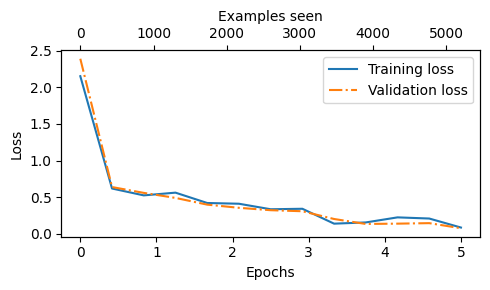

In [38]:
import matplotlib.pyplot as plt


def plot_values(
    epochs_seen, examples_seen, train_values, val_values,
    label="loss"
):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(
        epochs_seen, train_values,
        label=f"Training {label}"
    )
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()


epochs_tensor = torch.linspace(
    0, num_epochs, len(train_losses)
)

examples_seen_tensor = torch.linspace(
    0, examples_seen, len(train_losses)
)

plot_values(
    epochs_tensor,
    examples_seen_tensor,
    train_losses,
    val_losses
)

손실 그래프에서 알 수 있듯이 손실은 첫 번째 에포크에서 가파르게 감소하고 다섯 번째 에포크에 가까워지면서 점차 안정화된다, 이는 모델이 훈련 데이터로부터 잘 학습되고 있으며 과대 적합의 징후가 거의 없다는 것이다. 즉, 훈련 세트 손실과 검증 세트 손실 사이에 눈에 띄는 차이가 없다.

plot_values 함수를 사용해 분류 정확도를 그려보자.

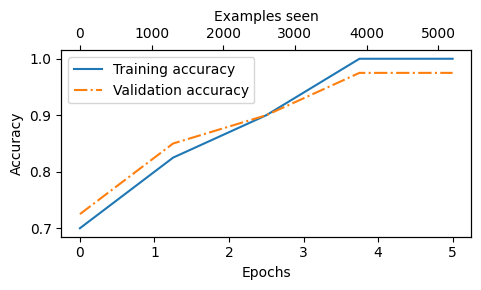

In [39]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(
    0, examples_seen, len(train_accs)
)
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

위 코드로 얻은 정확도 그래프이다. 이 모델은 에포크 4와 5 이후에 비교적 높은 훈련 정확도와 검증 정확도를 달성한다.

이제 다음 코드를 사용해 전체 데이터셋에서 훈련 세트, 검증 세트, 테스트 세트에 대한 성능을 계산해야 한다. 이번에는 eval_iter 매개변수를 지정하지 않는다.

In [40]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"훈련 정확도: {train_accuracy*100:.2f}%")
print(f"검증 정확도: {val_accuracy*100:.2f}%")
print(f"테스트 정확도: {test_accuracy*100:.2f}%")

훈련 정확도: 97.21%
검증 정확도: 97.32%
테스트 정확도: 95.67%


훈련 세트 성능과 테스트 세트 성능이 거의 비슷하다. 훈련 세트와 테스트 세트 정확도 사이에 있는 약간의 차이는 훈련 데이터에 대한 과대적합이 미미하다는 것을 알 수 있다.

## 6.8 LLM을 스팸 분류기로 사용하기
모델을 미세 튜닝하고 평가했으므로 이제 스팸 메시지를 분류할 차례이다. 미세 튜닝된 GPT 기반 스팸 분류 모델을 사용해보자. classify_review 함수는 앞서 구현한 SpamDataset에서 사용한 것과 비슷한 데이터 전처리 단계를 수행한다. 그런 다음 텍스트를 토큰 ID로 변환한 후에 모델을 사용해 정수 클래스 레이블을 예측한다. 그런 다음 레이블에 해당하는 클래스 이름을 반환한다.

In [41]:
def classify_review(
    text, model, tokenizer, device, max_length=None,
    pad_token_id=50256):
  model.eval()

  input_ids = tokenizer.encode(text) # 모델을 위해 입력을 준비한다
  supported_context_length = model.pos_emb.weight.shape[0]

  input_ids = input_ids[:min(
      max_length, supported_context_length
  )]

  input_ids += [pad_token_id] * (max_length - len(input_ids)) # 가장 긴 시퀀스에 맞춰 패딩 추가

  input_tensor = torch.tensor(
      input_ids, device=device
  ).unsqueeze(0)

  with torch.no_grad(): # 모델 추론을 위해 그레이디언트 추정을 끈다
    logits = model(input_tensor)[:, -1, :] # 마지막 출력 토큰의 로짓
  predicted_label = torch.argmax(logits, dim=-1).item()

  return "스팸" if predicted_label == 1 else "스팸 아님" # 분류된 결과 반환

classify_review 함수를 샘플 텍스트에 적용해본다.

In [43]:
text_1 = (
    "You are a winner you have been specially"
    " selected to recieve $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

스팸


모델이 정확하게 '스팸'이라고 예측한다. 다른 샘플을 테스트해보자.

In [44]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    "for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

스팸 아님


모델이 다시 올바르게 예측하여 '스팸 아님' 레이블을 반환한다.